# Building a Custom LLM with nanoGPT
**Class 4 | From Zero to AI Agents | Fall 26**

Train from scratch using **Karpathy's actual nanoGPT transformer** in PyTorch.
Our classroom tokenizer uses **whole words and punctuation**. nanoGPT does not
dictate tokenization: its examples include characters and GPT-2 subwords. Word
tokens are our teaching choice, not a new architecture or pretrained embeddings.
Your job is to choose, predict, run, inspect, and explain, not implement the network.
A small model on a narrow corpus is not a chat assistant or a general map of meaning.

[Assignment](https://docs.google.com/document/d/1MQ3YQl2ywWZF7W5_l_91FiIp7pTYPO_3viI2JVapRcc/edit)
| [Sample project](https://github.com/pepealonso95/custom-llm)
| [nanoGPT source](https://github.com/karpathy/nanoGPT)

## 1. Make three choices
**Corpus:** put PDF, TXT or Markdown files in `corpus/` to expand the supplied
classroom sentences. Set CORPUS="folder" to use only your files instead.
**Training steps:** 10 checks setup; start with 3,000 for the experiment. One step
updates weights using 32 documents, not the entire corpus. Try 5,000 or 10,000 later
if useful, but compare validation loss rather than assuming more is better.
**Learning rate:** start at 0.001, with warmup and cosine decay in the training cell.
Write your reasons and prediction before running, and explain the actual outputs.

In [ ]:
CORPUS = "classroom"       # Teaching sentences + files; "folder" uses only files
CORPUS_FOLDER = "corpus"   # Add .pdf, .txt and .md files here, including subfolders
TRAINING_STEPS = 3000      # 10 for setup; 3000 for the main experiment
LEARNING_RATE = 0.001

### My prediction

I chose the supplied synthetic classroom corpus because it is permitted, reproducible, and large enough to demonstrate how repeated word-level patterns are learned without introducing private or copyrighted files. I chose 3,000 training steps because this is the assignment's recommended baseline budget: long enough to observe learning while remaining practical on a CPU. I chose an initial learning rate of 0.001 because the notebook's warmup and cosine decay should make useful updates without the instability of an excessively large rate or the very slow learning of an excessively small rate.

Before training, I expect the randomly initialized model to generate mostly incoherent token sequences and to assign fairly diffuse next-token probabilities. By 1,500 and 3,000 steps, I expect both fixed-panel training and validation loss to decrease, and I expect generated samples to reproduce more of the classroom corpus's sentence templates and domain groupings. For the word **customer**, I expect its 64-number embedding to change and its closest neighbors to move toward related words such as client, buyer, shopper, consumer, or subscriber. Because the corpus is synthetic and repetitive and validation uses the same templates, I do not expect plausible samples or lower validation loss to demonstrate broad language understanding or generalization to new domains.

## 2. Load the tools and network
Colab generally includes PyTorch. Locally, install requirements.txt first.
Setup installs the small pypdf package if absent and creates the corpus folder.
In Colab, run this setup cell, upload files into /content/corpus via the Files
sidebar, then Run All. Opening from GitHub does not copy your local files.
This cell fetches only the pinned nanoGPT source if absent and checks its hash.
Training defaults to CPU. GPU optimization is optional; no API keys or pretrained
weights are used. nanoGPT's model.py and MIT license are included in the repository.

In [ ]:
import csv
import hashlib
import importlib.util
import json
import math
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
import torch
from torch.nn import functional as F

if importlib.util.find_spec("pypdf") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pypdf>=5,<7"])
Path(CORPUS_FOLDER).mkdir(parents=True, exist_ok=True)

if isinstance(TRAINING_STEPS, bool) or not isinstance(TRAINING_STEPS, int) or TRAINING_STEPS < 1:
    raise ValueError("TRAINING_STEPS must be a positive whole number.")
if isinstance(LEARNING_RATE, bool) or not isinstance(LEARNING_RATE, (int, float)) or not math.isfinite(LEARNING_RATE) or LEARNING_RATE <= 0:
    raise ValueError("LEARNING_RATE must be finite and positive.")
UPSTREAM_COMMIT = "3adf61e154c3fe3fca428ad6bc3818b27a3b8291"
UPSTREAM_SHA256 = "7c01703240dbec5d554527dc666e35b3df8391d0b117fddc07afcf325a21d11c"
model_file = Path("nanogpt_model.py")
if not model_file.exists():
    with urllib.request.urlopen(f"https://raw.githubusercontent.com/karpathy/nanoGPT/{UPSTREAM_COMMIT}/model.py", timeout=30) as response:
        source = response.read()
    if hashlib.sha256(source).hexdigest() != UPSTREAM_SHA256:
        raise ValueError("Downloaded nanoGPT source failed its hash check.")
    model_file.write_bytes(source)
if hashlib.sha256(model_file.read_bytes()).hexdigest() != UPSTREAM_SHA256:
    raise ValueError("nanoGPT source differs from the pinned version. Restore the supplied file.")
spec = importlib.util.spec_from_file_location("classroom_nanogpt", model_file)
nanogpt = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = nanogpt
spec.loader.exec_module(nanogpt)
SEED, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, BATCH_SIZE = 42, 64, 4, 2, 48, 32
DEVICE = "cpu"  # Optional: "cuda" on a Colab GPU, or "mps" on Apple Silicon
torch.set_num_threads(min(4, torch.get_num_threads()))
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__, "| device:", DEVICE)

PyTorch: 2.11.0+cpu | device: cpu


## 3. Meet the corpus
A **corpus** is a collection of examples. The default generator creates sentences
about business, food, transport, technology, health, and education. Related nouns
deliberately share contexts. **No category labels or coordinates go into the model
or viewer.** The model receives only sentence text for next-token prediction.
This is a controlled demonstration, not evidence of broad semantic understanding.

We deduplicate normalized documents and hold out 10% before building the vocabulary.
Validation contains new sentences from the SAME templates, not new domains/templates.
Add PDFs with selectable text, UTF-8 TXT, or Markdown to corpus/. The default adds
their text to these sentences; "folder" uses only files and requires 100 passages.
Long text is split into non-overlapping passages of at most 47 tokens, not truncated.
Markdown is plain text; links/code are never fetched or executed. Scans need OCR first.
Inspect corpus_manifest.json for file previews, counts and extraction warnings.
The random split is by unique passage, not source file: passages from the same file
can appear in both sets. This does not test generalization to unseen documents.
Adding files requires Run All to retrain; it is not retrieval or instant knowledge.
Files in corpus/ are Git-ignored, but the results ZIP includes extracted text.

In [ ]:
def word_tokens(text):
    return re.findall(r"\w+(?:['’]\w+)*|[^\w\s]", text.lower(), flags=re.UNICODE)

def chunk_text(text, max_tokens=47):
    """Keep sentence/line boundaries when possible; split long units without overlap."""
    chunks = []
    for unit in re.split(r"(?<=[.!?])\s+|\n+", text):
        tokens = word_tokens(unit)
        chunks.extend(" ".join(tokens[i:i+max_tokens]) for i in range(0, len(tokens), max_tokens))
    return chunks

def load_corpus_folder(folder, max_tokens=47):
    """Read only local, supported regular files. Never fetch document links or do OCR."""
    from pypdf import PdfReader
    root = Path(folder).resolve()
    if not root.is_dir():
        raise ValueError(f"Corpus folder not found: {root}. Create it and add PDF, TXT or MD files.")
    chunks, records, ignored = [], [], []
    paths = []
    for path in sorted(root.rglob("*")):
        relative = path.relative_to(root)
        if any(part.startswith(".") for part in relative.parts) or path == root/"README.md":
            continue
        if any(root.joinpath(*relative.parts[:i]).is_symlink() for i in range(1, len(relative.parts)+1)):
            ignored.append({"file":str(relative), "reason":"symbolic link"})
            continue
        if not path.is_file():
            continue
        if path.suffix.lower() not in {".pdf", ".txt", ".md"}:
            ignored.append({"file":str(relative), "reason":"unsupported extension"})
            continue
        paths.append(path)
    if len(paths) > 50 or sum(p.stat().st_size for p in paths) > 100*1024*1024:
        raise ValueError("Use at most 50 supported corpus files and 100 MB total.")
    for path in paths:
        relative = str(path.relative_to(root))
        size = path.stat().st_size
        if size > 25*1024*1024:
            raise ValueError(f"{relative}: exceeds the classroom limit of 25 MB per file.")
        data = path.read_bytes()
        record = {"file":relative, "bytes":size, "sha256":hashlib.sha256(data).hexdigest(), "warnings":[]}
        try:
            if path.suffix.lower() == ".pdf":
                import io
                reader = PdfReader(io.BytesIO(data))
                if reader.is_encrypted:
                    raise ValueError("encrypted PDF; export an unlocked copy you are allowed to use")
                if len(reader.pages) > 200:
                    raise ValueError("PDF exceeds 200 pages; use a smaller excerpt")
                pages = []
                record["pages"] = len(reader.pages)
                for number, page in enumerate(reader.pages, 1):
                    page_text = page.extract_text() or ""
                    if not page_text.strip():
                        record["warnings"].append(f"Page {number}: no text extracted (blank or scanned); OCR may be needed.")
                    pages.append(page_text)
                    if sum(map(len, pages)) > 2_000_000:
                        raise ValueError("extracted text exceeds 2 million characters")
                text = "\n".join(pages)
            else:
                text = data.decode("utf-8-sig")
            if not any(character.isalnum() for character in text):
                raise ValueError("no readable text; empty files and image-only PDFs cannot train this model. Run OCR on scans first")
            if len(text) > 2_000_000:
                raise ValueError("text exceeds 2 million characters")
            file_chunks = chunk_text(text, max_tokens)
        except Exception as exc:
            raise ValueError(f"Could not import {relative}: {exc}") from exc
        record.update({"characters":len(text), "passages":len(file_chunks), "unique_passages":len(set(file_chunks)), "preview":text[:300]})
        records.append(record)
        chunks.extend(file_chunks)
    return chunks, {"files":records, "ignored":ignored, "external_passages":len(chunks)}

def classroom_corpus():
    domains = [
        ("customer client buyer shopper consumer subscriber", "service purchase support order", "store"),
        ("product item package brand merchandise offering", "price quality delivery design", "market"),
        ("loan credit mortgage investment bond deposit", "interest risk payment return", "bank"),
        ("apple banana orange pear peach mango", "fruit taste juice harvest", "kitchen"),
        ("car bus train truck taxi bicycle", "travel route traffic journey", "station"),
        ("software application program platform website system", "code data security update", "office"),
        ("doctor nurse physician surgeon therapist dentist", "patient health care treatment", "hospital"),
        ("teacher tutor instructor professor educator lecturer", "student lesson course learning", "school"),
    ]
    sentences = []
    for nouns, contexts, place in domains:
        for noun in nouns.split():
            for context in contexts.split():
                for adjective in ["new", "local", "important", "different"]:
                    for frame in [
                        "the team discussed the {noun} and the {context} at the {place} .",
                        "we learned about the {adjective} {noun} during a discussion of {context} .",
                        "the report about the {noun} explains the {context} in detail .",
                        "our {place} has a question about the {adjective} {noun} and {context} .",
                        "they compared the {adjective} {noun} with another {noun} at the {place} .",
                        "a review of {context} helped us understand the {adjective} {noun} .",
                        "today the {place} focused on {context} and the {adjective} {noun} .",
                        "the {adjective} {noun} was mentioned in the {context} report yesterday .",
                    ]:
                        sentences.append(frame.format(noun=noun, context=context, place=place, adjective=adjective))
    for noun in "customer client buyer shopper consumer subscriber".split():
        for product in "product item package brand merchandise offering".split():
            for verb in "ordered reviewed compared returned recommended selected".split():
                sentences.append(f"the {noun} {verb} the {product} after checking the price .")
    return "\n".join(sentences)

extra_chunks, corpus_manifest = load_corpus_folder(CORPUS_FOLDER, BLOCK_SIZE-1)
if CORPUS == "classroom":
    base_text = classroom_corpus()
    corpus_source = "Synthetic classroom sentences plus corpus folder files"
elif CORPUS == "folder":
    if not corpus_manifest["files"]:
        raise ValueError("CORPUS='folder' needs PDF, TXT or MD files in CORPUS_FOLDER. No readable files were found.")
    base_text = ""
    corpus_source = "Corpus folder files only"
else:
    base_text = Path(CORPUS).read_text(encoding="utf-8-sig")
    corpus_source = "Custom UTF-8 base file plus corpus folder files"
base_chunks = chunk_text(base_text, BLOCK_SIZE-1)
all_chunks = base_chunks + extra_chunks
raw_text = "\n".join(all_chunks)
docs = sorted(set(all_chunks))
corpus_manifest.update({"mode":CORPUS, "base_passages":len(base_chunks), "unique_passages":len(docs),
    "new_unique_passages":len(set(extra_chunks)-set(base_chunks)), "duplicates_removed":len(all_chunks)-len(docs),
    "max_passage_tokens":BLOCK_SIZE-1, "split_unit":"deduplicated passage, not source file"})
if len(docs) < 100:
    raise ValueError(f"Found {len(docs)} unique passages. Add more text to reach 100, or use CORPUS='classroom' to include the teaching corpus.")
random.Random(SEED).shuffle(docs)
cut = int(.9 * len(docs))
train_docs, val_docs = docs[:cut], docs[cut:]
eval_train = random.Random(123).sample(train_docs, min(20, len(train_docs)))
eval_val = random.Random(456).sample(val_docs, min(20, len(val_docs)))
run_dir = Path("llm_runs") / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
(run_dir / "samples").mkdir(parents=True)
def save_json(name, data):
    (run_dir / name).write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
(run_dir / "corpus.txt").write_text(raw_text, encoding="utf-8")
save_json("corpus_manifest.json", corpus_manifest)
save_json("split.json", {"train": train_docs, "validation": val_docs, "evaluation_train": eval_train, "evaluation_validation": eval_val})
print("Source:", corpus_source)
print("Imported files:", len(corpus_manifest["files"]), "| new unique passages:", corpus_manifest["new_unique_passages"])
for entry in corpus_manifest["files"]:
    print(entry["file"], "→", entry["passages"], "passages", "| preview:", repr(entry["preview"][:100]))
    for warning in entry["warnings"]:
        print("WARNING:", warning)
for entry in corpus_manifest["ignored"]:
    print("IGNORED:", entry)
print(f"Unique documents: {len(docs):,} | train: {len(train_docs):,} | validation: {len(val_docs):,}")
print("Five training documents:", *train_docs[:5], sep="\n")

Source: Synthetic classroom sentences plus corpus folder files
Imported files: 0 | new unique passages: 0
Unique documents: 4,632 | train: 4,168 | validation: 464
Five training documents:
a review of interest helped us understand the different mortgage .
we learned about the different consumer during a discussion of order .
the important deposit was mentioned in the return report yesterday .
a review of interest helped us understand the local loan .
they compared the local apple with another apple at the kitchen .


## 4. Words → tokens → IDs
A token is a unit of text: here a word or punctuation mark. IDs are arbitrary row
numbers, not quantities of meaning. Build the vocabulary ONLY from training text.
Validation-only words become `<UNK>`; report that rate. `<BOS>` starts and `<EOS>`
ends a passage. To keep the classroom model small, retain the 509 most frequent
training word/punctuation types (token strings up to 128 characters); other tokens
become UNK. The coverage report makes this loss visible. Adding a large, diverse
corpus may mostly add unknown words, so inspect the rates and choose focused text.
Lowercasing and spacing normalization are deliberate: decoding
does not restore original capitalization or whitespace.

In [ ]:
counts = Counter(token for doc in train_docs for token in word_tokens(doc))
retained = sorted((t for t in counts if len(t) <= 128), key=lambda t:(-counts[t], t))[:509]
vocabulary = ["<UNK>", "<BOS>", "<EOS>"] + sorted(retained)
stoi = {token: i for i, token in enumerate(vocabulary)}
UNK, BOS, EOS = 0, 1, 2
def encode(text):
    return [stoi.get(token, UNK) for token in word_tokens(text)]
def decode(ids):
    return " ".join(vocabulary[i] for i in ids)
def tokenize(doc):
    return [BOS] + encode(doc) + [EOS]
validation_ids = [i for doc in val_docs for i in encode(doc)]
unknown_rate = validation_ids.count(UNK) / max(1, len(validation_ids))
training_unknown_rate = sum(counts[t] for t in counts if t not in stoi) / max(1, sum(counts.values()))
save_json("vocabulary_report.json", {"training_types":len(counts), "retained_types":len(retained),
    "training_unknown_rate":training_unknown_rate, "validation_unknown_rate":unknown_rate,
    "omitted_types":sorted(set(counts)-set(retained))})
example, example_ids = train_docs[0], tokenize(train_docs[0])
probe_word = "customer" if "customer" in stoi else vocabulary[3]
probe_id = stoi[probe_word]
prefix = "the customer" if "customer" in stoi else decode(encode(example)[:3])
save_json("tokenization.json", {"type": "word", "vocabulary": vocabulary, "example": example, "ids": example_ids, "inputs": example_ids[:-1], "targets": example_ids[1:], "validation_unknown_rate": unknown_rate})
print("Vocabulary:", len(vocabulary), "| held-out unknown-token rate:", f"{unknown_rate:.2%}")
print("Training unknown-token rate:", f"{training_unknown_rate:.2%}", "| omitted types:", len(counts)-len(retained))
if training_unknown_rate > .05 or unknown_rate > .05:
    print("WARNING: more than 5% of tokens are UNK in at least one split. Consider a more focused corpus.")
print("Text:", example, "\nTokens:", word_tokens(example), "\nIDs:", example_ids)
print("Input → target:", list(zip(decode(example_ids[:-1]).split(), decode(example_ids[1:]).split())))

Vocabulary: 136 | held-out unknown-token rate: 0.00%
Training unknown-token rate: 0.00% | omitted types: 0
Text: a review of interest helped us understand the different mortgage . 
Tokens: ['a', 'review', 'of', 'interest', 'helped', 'us', 'understand', 'the', 'different', 'mortgage', '.'] 
IDs: [1, 4, 97, 71, 52, 47, 130, 128, 118, 35, 68, 3, 2]
Input → target: [('<BOS>', 'a'), ('a', 'review'), ('review', 'of'), ('of', 'interest'), ('interest', 'helped'), ('helped', 'us'), ('us', 'understand'), ('understand', 'the'), ('the', 'different'), ('different', 'mortgage'), ('mortgage', '.'), ('.', '<EOS>')]


## 5. Neural network and embedding table
The upstream nanoGPT GPT uses 2 blocks, 4 heads, 64-number embeddings, a 48-token
context, LayerNorm, GELU, residual connections and tied input/output embeddings.
PyTorch computes gradients. An embedding is a learned row of numbers, not its ID.
Token and position embeddings combine; attention mixes earlier context; nonlinear
feed-forward layers transform it; output scores become next-token probabilities.
Point to a word, its ID, all 64 numbers, and the complete table's shape.

In [ ]:
model_config = nanogpt.GPTConfig(vocab_size=len(vocabulary), block_size=BLOCK_SIZE,
    n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD, dropout=0.0, bias=True)
model = nanogpt.GPT(model_config).to(DEVICE)
initial_embeddings = model.transformer.wte.weight.detach().cpu().clone()
embedding_before = initial_embeddings[probe_id].tolist()
print("Embedding table:", tuple(initial_embeddings.shape), "| parameters:", sum(p.numel() for p in model.parameters()))
print("Word:", probe_word, "| ID:", probe_id, "\nInitial vector:", embedding_before)
a = torch.tensor(2.0, requires_grad=True)
loss_demo = a * a + a
loss_demo.backward()
print("For a*a+a at a=2, the gradient is", a.grad.item(), "(2*a+1).")

number of parameters: 0.11M
Embedding table: (136, 64) | parameters: 111872
Word: customer | ID: 28 
Initial vector: [-0.057591915130615234, -0.004809952806681395, 0.04263188689947128, 0.019338956102728844, 0.015643136575818062, -0.02882436476647854, 0.025609055534005165, 5.246092769084498e-05, 0.02470681630074978, 0.0206917654722929, 0.0073690167628228664, -0.033089615404605865, -0.05354786291718483, -0.0057429298758506775, -0.024166762828826904, -0.014716118574142456, 0.004685705993324518, -0.01045426819473505, -0.008381075225770473, -0.018258560448884964, -0.020133700221776962, 0.005098649766296148, -0.010916502214968204, -0.012633351609110832, 0.028389625251293182, -0.002631223062053323, -0.004071928560733795, 0.013641919940710068, -0.009891724213957787, -0.01671762391924858, 0.0019060791237279773, -0.0014535071095451713, 0.01602652110159397, -0.005674874875694513, -0.0006723481928929687, -0.001290727173909545, -0.0073194727301597595, -0.0009307070868089795, 0.001507619977928698, -

## 6. Predictions, loss, and a fair baseline
Loss penalizes low probability on the observed next token. Backpropagation computes
gradients; AdamW updates weights. Right-padding targets are ignored. Causal attention
prevents predictions from seeing future tokens, including right padding.
Evaluate fixed panels of up to 20 documents before, halfway through and after training.
Loss is the mean over all non-padding next-token targets in each panel. Generation
uses a separate fixed sampling seed and never updates the weights.

In [ ]:
def batch(documents):
    sequences = [tokenize(doc) for doc in documents]
    length = max(len(seq)-1 for seq in sequences)
    x = torch.full((len(sequences), length), EOS, dtype=torch.long, device=DEVICE)
    y = torch.full_like(x, -1)
    for i, seq in enumerate(sequences):
        x[i, :len(seq)-1] = torch.tensor(seq[:-1], device=DEVICE)
        y[i, :len(seq)-1] = torch.tensor(seq[1:], device=DEVICE)
    return x, y

@torch.no_grad()
def evaluate(documents):
    model.eval()
    return model(*batch(documents))[1].item()

@torch.no_grad()
def probabilities(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    return F.softmax(model(ids)[0][0, -1], dim=-1).cpu().tolist()

@torch.no_grad()
def generate(temperature=.8, seed=2026, count=4):
    model.eval()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    samples = []
    for _ in range(count):
        ids, output = [BOS], []
        for _ in range(32):
            logits = model(torch.tensor([ids[-BLOCK_SIZE:]], device=DEVICE))[0][0, -1].cpu()
            next_id = torch.multinomial(F.softmax(logits/temperature, dim=-1), 1, generator=generator).item()
            if next_id == EOS:
                break
            ids.append(next_id)
            output.append(next_id)
        samples.append(decode(output))
    return samples

history = []
def record(step):
    row = {"step": step, "training_loss": evaluate(eval_train), "validation_loss": evaluate(eval_val)}
    history.append(row)
    samples = generate()
    (run_dir/"samples"/f"step_{step:04d}.txt").write_text("\n".join(samples), encoding="utf-8")
    save_json("history.json", history)
    print(row, "\nSamples:", *samples, sep="\n")
probabilities_before = probabilities(prefix)
record(0)

{'step': 0, 'training_loss': 4.923802852630615, 'validation_loss': 4.924667835235596}

Samples:
pear professor bond doctor course harvest team physician journey checking buyer delivery traffic report the lecturer item offering and system <UNK> taste recommended mentioned bus question customer at mortgage nurse in instructor
kitchen purchase journey product question discussion journey service . nurse local
compared and purchase update mortgage question loan taste in market treatment learned another item bicycle product bicycle focused data and dentist recommended mango apple taxi bicycle delivery peach quality update student lesson
important hospital juice patient return recommended deposit tutor returned understand kitchen student design ordered hospital treatment important package traffic with yesterday investment important of mentioned store ordered mortgage nurse shopper the station


## 7. Train: examples → predictions → loss → gradients → updates
Only training documents enter these batches. Save one real gradient and the first
embedding update. AdamW is not simply learning-rate times gradient: momentum,
adaptive scaling and weight decay matter. More steps may improve fit but low loss
on repeated sentence templates does not demonstrate broad understanding.
Change section 1 and Run All for a fresh experiment with a larger training budget.

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, betas=(.9, .95), weight_decay=.01)
sampling_rng = random.Random(SEED+1)
completed_steps, first_update, interrupted = 0, None, False
start = time.perf_counter()
milestones = {max(1, TRAINING_STEPS//2), TRAINING_STEPS}
try:
    for step in range(TRAINING_STEPS):
        warmup = min(100, max(1, TRAINING_STEPS//10))
        progress = max(0, step-warmup)/max(1, TRAINING_STEPS-warmup)
        lr = LEARNING_RATE*min(1, (step+1)/warmup)*(.1+.9*.5*(1+math.cos(math.pi*progress)))
        for group in optimizer.param_groups:
            group["lr"] = lr
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(*batch(sampling_rng.choices(train_docs, k=BATCH_SIZE)))
        if not torch.isfinite(loss):
            raise FloatingPointError("Nonfinite loss. Lower the learning rate and restart.")
        loss.backward()
        if step == 0:
            first_update = {"token": probe_word, "coordinate": 0, "before": model.transformer.wte.weight[probe_id,0].item(), "gradient": model.transformer.wte.weight.grad[probe_id,0].item(), "learning_rate": lr}
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
        optimizer.step()
        completed_steps = step+1
        if step == 0:
            first_update["after"] = model.transformer.wte.weight[probe_id,0].item()
        if completed_steps in milestones:
            record(completed_steps)
        elif completed_steps % 500 == 0:
            print(f"Step {completed_steps:,}: batch loss {loss.item():.4f}")
except KeyboardInterrupt:
    interrupted = True
    print("Interrupted. Continue the remaining cells to save completed work.")
elapsed = time.perf_counter()-start
if history[-1]["step"] != completed_steps:
    record(completed_steps)
print("Completed:", completed_steps, "| seconds:", round(elapsed,2), "\nFirst update:", first_update)

Step 500: batch loss 0.7878
Step 1,000: batch loss 0.6983
{'step': 1500, 'training_loss': 0.6928598284721375, 'validation_loss': 0.7112608551979065}

Samples:
our school has a question about the new educator and lesson .
a review of risk helped us understand the different deposit .
the report about the nurse explains the health in detail .
the consumer compared the merchandise after checking the price .
Step 2,000: batch loss 0.6852
Step 2,500: batch loss 0.6950
{'step': 3000, 'training_loss': 0.6955571174621582, 'validation_loss': 0.7056517004966736}

Samples:
our school has a question about the new educator and lesson .
a review of risk helped us understand the different deposit .
the report about the nurse explains the health in detail .
the consumer compared the merchandise after checking the price .
Completed: 3000 | seconds: 35.78 
First update: {'token': 'customer', 'coordinate': 0, 'before': -0.057591915130615234, 'gradient': -0.0004056147299706936, 'learning_rate': 1e-05, 'aft

## 8. Inspect changed vectors, predictions and attention
Compare the same word/prefix before and after. Attention below is head 1 in block 1,
calculated from the actual trained query/key projections with the same causal mask.
It is not an embedding or a universal explanation of the model. The viewer exports
all initial/final token vectors. PCA loses information; cosine neighbors use all 64
dimensions. Narrow template-trained embeddings may differ from human meaning judgments.

In [ ]:
@torch.no_grad()
def inspect_attention(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    length = ids.shape[1]
    x = model.transformer.wte(ids)+model.transformer.wpe(torch.arange(length, device=DEVICE))
    block = model.transformer.h[0]
    q, k, _ = block.attn.c_attn(block.ln_1(x)).split(N_EMBD, dim=-1)
    q = q.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    k = k.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    scores = q@k.transpose(-2,-1)/math.sqrt(N_EMBD//N_HEAD)
    scores = scores.masked_fill(torch.triu(torch.ones(length,length,device=DEVICE),diagonal=1).bool(), float("-inf"))
    return F.softmax(scores,dim=-1)[0,0].cpu().tolist()
embedding_after = model.transformer.wte.weight[probe_id].detach().cpu().tolist()
probabilities_after = probabilities(prefix)
attention_rows = inspect_attention(prefix)
save_json("inspection.json", {"token": probe_word, "token_id": probe_id, "embedding_before": embedding_before,
    "embedding_after": embedding_after, "first_update": first_update, "prefix": prefix,
    "probabilities_before": probabilities_before, "probabilities_after": probabilities_after, "attention_rows": attention_rows})
print("Word:", probe_word, "\nTrained vector:", embedding_after)
for name, probs in [("Before",probabilities_before),("After",probabilities_after)]:
    print(name, "predictions:", [(vocabulary[i],round(probs[i],4)) for i in sorted(range(len(probs)),key=probs.__getitem__,reverse=True)[:5]])
print("First-head attention:", attention_rows)
temperatures = {str(t):generate(temperature=t) for t in [.3,.8,1.2]}
save_json("temperature_comparison.json", temperatures)
print("Temperature comparison:", json.dumps(temperatures,indent=2))

Word: customer 
Trained vector: [0.03709550201892853, -0.004770858678966761, 0.1357932835817337, 0.12259624153375626, 0.07157423347234726, 0.031156593933701515, 0.1410778909921646, 0.09497924894094467, -0.07123769074678421, -0.011708877049386501, 0.011737842112779617, -0.059505946934223175, -0.039963267743587494, -0.08282631635665894, -0.14553362131118774, -0.030693694949150085, -0.16128674149513245, -0.1482156366109848, 0.0015606125816702843, -0.066569484770298, -0.07938406616449356, 0.010203034617006779, -0.07635767012834549, -0.008454341441392899, 0.023043528199195862, -0.06297734379768372, 0.11937720328569412, -0.03988614305853844, 0.03164634108543396, -0.15456311404705048, -0.0869724228978157, 0.07473238557577133, -0.04121365398168564, 0.13912783563137054, 0.08229125291109085, 0.07174324989318848, 0.01575295254588127, -0.15111741423606873, 0.09685888141393661, -0.03868136554956436, 0.06345273554325104, -0.016498789191246033, -0.13917434215545654, 0.03919057175517082, -0.0260660350

## 9. Save evidence and open the viewer
Download the results ZIP AND the executed notebook separately after the final cell.
Open `embedding-viewer.html` from the repository, choose **Open your checkpoint**,
and select `checkpoint.json` from the extracted ZIP. It contains final AND recorded
initial embeddings, not all network weights. `model.pt` contains the full network
for inference; neither file is an exact training-resume state. To increase the
budget, restart from the top. Keep private data out of shared ZIPs: they include text.

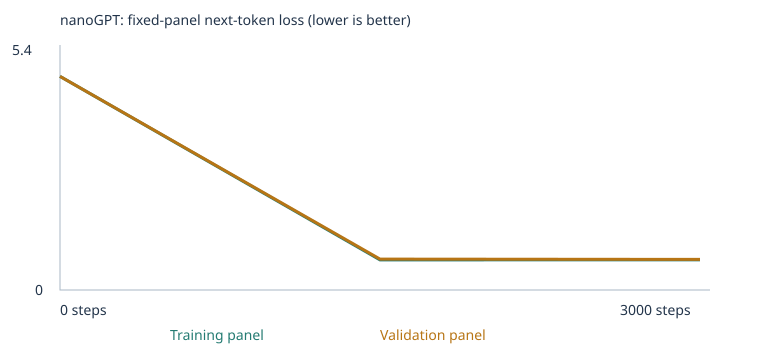

/content/llm_runs/20260916T043011_961972Z.zip

Saved: llm_runs/20260916T043011_961972Z 
Results ZIP: /content/llm_runs/20260916T043011_961972Z.zip


In [ ]:
config = {"model":"nanoGPT", "upstream_commit":UPSTREAM_COMMIT, "tokenizer":"word", "corpus_source":corpus_source,
    "corpus_sha256":hashlib.sha256(raw_text.encode()).hexdigest(), "training_steps":TRAINING_STEPS,
    "learning_rate":LEARNING_RATE, "seed":SEED, "n_embd":N_EMBD, "n_head":N_HEAD, "n_layer":N_LAYER,
    "block_size":BLOCK_SIZE, "batch_size":BATCH_SIZE, "vocabulary_size":len(vocabulary),
    "parameters":sum(p.numel() for p in model.parameters()), "train_documents":len(train_docs),
    "validation_documents":len(val_docs), "validation_unknown_rate":unknown_rate, "training_unknown_rate":training_unknown_rate,
    "corpus_files":len(corpus_manifest["files"]), "corpus_mode":CORPUS,
    "evaluation_panel_size":{"train":len(eval_train),"validation":len(eval_val)},
    "evaluation_reduction":"mean over non-padding next-token panel targets",
    "python":sys.version,"torch":str(torch.__version__),"device":DEVICE,"hardware":platform.platform()}
save_json("config.json",config)
save_json("training_summary.json",{"completed_steps":completed_steps,"elapsed_seconds":elapsed,"interrupted":interrupted})
save_json("checkpoint.json",{"format":"classroom-nanogpt-embeddings-v1","config":config,"vocabulary":vocabulary,
    "completed_steps":completed_steps,"weights":{"wte":model.transformer.wte.weight.detach().cpu().tolist()},
    "initial_embeddings":initial_embeddings.tolist(),"token_counts":[counts.get(t,0) for t in vocabulary]})
torch.save({"model":{k:v.detach().cpu() for k,v in model.state_dict().items()},"model_args":vars(model_config),
    "vocabulary":vocabulary,"completed_steps":completed_steps},run_dir/"model.pt")
with (run_dir/"training.csv").open("w",newline="") as file:
    writer = csv.DictWriter(file,fieldnames=["step","training_loss","validation_loss"])
    writer.writeheader()
    writer.writerows(history)
upper = max(row[key] for row in history for key in ["training_loss","validation_loss"])*1.1
def points(key):
    return " ".join(f"{60+row['step']/max(1,completed_steps)*640:.1f},{290-row[key]/upper*235:.1f}" for row in history)
svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="760" height="350" viewBox="0 0 760 350">
<rect width="760" height="350" fill="white"/><g font-family="sans-serif" font-size="14" fill="#22344a">
<text x="60" y="25">nanoGPT: fixed-panel next-token loss (lower is better)</text>
<path d="M60 45V290H710" fill="none" stroke="#aab8c6"/><text x="35" y="295">0</text>
<text x="12" y="55">{upper:.1f}</text><text x="60" y="315">0 steps</text><text x="620" y="315">{completed_steps} steps</text>
<polyline points="{points('training_loss')}" fill="none" stroke="#247b72" stroke-width="3"/>
<polyline points="{points('validation_loss')}" fill="none" stroke="#b77515" stroke-width="3"/>
<text x="170" y="340" fill="#247b72">Training panel</text><text x="380" y="340" fill="#b77515">Validation panel</text></g></svg>'''
(run_dir/"training_curves.svg").write_text(svg)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
try:
    from IPython.display import SVG, FileLink, display
    display(SVG(svg))
    display(FileLink(archive))
except ImportError:
    pass
print("Saved:",run_dir,"\nResults ZIP:",archive)

## 10. Explain in your own words
Publication note: the ZIP link in the saved output above refers to the original
Colab runtime's temporary /content/llm_runs/ path; it is not a GitHub download.
Inspect the published [results folder](results/) and [README](README.md) instead.
A new Run All creates a new ZIP; download it before ending that runtime.
The saved code and measured outputs are unchanged by this documentation note.

1. What can your corpus teach? What does this particular held-out split test?
2. Trace one word through token, ID and 64-number embedding.
3. Connect a prediction, loss, gradient and the saved parameter update.
4. Which neighbors changed? Why is 3D proximity imperfect?
5. What changed in samples and validation loss? What remains unconvincing?
6. Explain attention, temperature and one next experiment. More training is not
   automatically better; a synthetic corpus does not demonstrate general knowledge.
Save the executed notebook, evidence and README in your own public repository.
Submit its URL through the course portal. A longer run is optional.